# Block-exact RTRL 与 reverse BPTT scaling

这个 notebook **只读取** Python benchmark runner 生成的 CSV，不运行仿真或编译。Benchmark 使用 A100、x64、`dt=0.025 ms`，每个配置/方法在独立进程中编译，并报告十次同步 steady execution 的中位数。

状态按 `(seed, batch, state, CV)` 组织；每个 seed 有独立的 `3*C` 参数并对同一 batch 求梯度。RTRL 在 seed 轴上使用 block-exact `vmap`，不保存跨 seed 恒零 sensitivity。

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "braincell").is_dir()
)
artifact_root = root / "examples/experimental/online_learning/artifacts/rtrl_bptt_scaling"
configured = os.environ.get("RTRL_BENCHMARK_DIR")
if configured:
    result_dirs = [Path(configured).expanduser().resolve()]
else:
    full_candidates = sorted(artifact_root.glob("full_*"), key=lambda path: path.stat().st_mtime)
    pilot_candidates = sorted(artifact_root.glob("pilot_*"), key=lambda path: path.stat().st_mtime)
    large_candidates = sorted(artifact_root.glob("large_cv_*"), key=lambda path: path.stat().st_mtime)
    ordinary_candidates = sorted(artifact_root.glob("backsub_ordinary_*"), key=lambda path: path.stat().st_mtime)
    primary = full_candidates[-1:] or pilot_candidates[-1:]
    result_dirs = primary + large_candidates[-1:] + ordinary_candidates[-1:]
    if not result_dirs:
        raise FileNotFoundError("Run rtrl_bptt_scaling_benchmark.py first.")

frames = []
for directory in result_dirs:
    frame = pd.read_csv(directory / "results.csv")
    frame["result_directory"] = str(directory)
    if "backsub" not in frame:
        frame["backsub"] = "recursive"
    else:
        frame["backsub"] = frame.backsub.fillna("recursive")
    frames.append(frame)
results = pd.concat(frames, ignore_index=True).drop_duplicates(["config_id", "method", "backsub"], keep="last")
all_ok = results[results.status == "ok"].copy()
ok = all_ok[all_ok.backsub == "recursive"].copy()
print("result directories:")
for directory in result_dirs:
    print("  ", directory)
print("successful trials:", len(all_ok), "/", len(results))
print("methods:", tuple(all_ok.method.unique()))
print("backsub modes:", tuple(all_ok.backsub.unique()))

result directories:
   /home/swl/braincell/examples/experimental/online_learning/artifacts/rtrl_bptt_scaling/full_block_exact
   /home/swl/braincell/examples/experimental/online_learning/artifacts/rtrl_bptt_scaling/large_cv_block_exact
   /home/swl/braincell/examples/experimental/online_learning/artifacts/rtrl_bptt_scaling/backsub_ordinary_block_exact
successful trials: 52 / 52
methods: ('bptt', 'rtrl')
backsub modes: ('recursive', 'ordinary')


## 结果总表

`temporary` 是 XLA static buffer analysis；`GPU peak` 是独立 worker 进程的 NVML allocation peak。后者包含 CUDA/JAX runtime 与 allocator 保留内存，适合看大规模增长，不等同于单个张量尺寸。

In [2]:
summary = ok[
    [
        "config_id",
        "method",
        "compile_seconds",
        "steady_median_seconds",
        "temporary_bytes",
        "rtrl_carry_bytes",
        "gpu_peak_steady_bytes",
        "bptt_over_rtrl_time",
        "gradient_max_rel_error",
    ]
].sort_values(["config_id", "method"])
formatted = summary.copy()
formatted["compile_seconds"] = formatted.compile_seconds.map(lambda value: f"{value:.3f}")
formatted["steady_median_seconds"] = formatted.steady_median_seconds.map(lambda value: f"{value:.4f}")
formatted["temporary_bytes"] = formatted.temporary_bytes.map(lambda value: f"{value / 2**20:.2f} MiB")
formatted["rtrl_carry_bytes"] = formatted.rtrl_carry_bytes.map(
    lambda value: "-" if pd.isna(value) else f"{value / 2**20:.3f} MiB"
)
formatted["gpu_peak_steady_bytes"] = formatted.gpu_peak_steady_bytes.map(lambda value: f"{value / 2**20:.1f} MiB")
formatted["bptt_over_rtrl_time"] = formatted.bptt_over_rtrl_time.map(lambda value: f"{value:.2f}x")
formatted["gradient_max_rel_error"] = formatted.gradient_max_rel_error.map(lambda value: f"{value:.2e}")
display(formatted)

,config_id,method,compile_seconds,steady_median_seconds,temporary_bytes,rtrl_carry_bytes,gpu_peak_steady_bytes,bptt_over_rtrl_time,gradient_max_rel_error
36,c13_t40_b16_s16,bptt,236.262,1.9433,3602.36 MiB,-,4610.0 MiB,2.67x,7.94e-09
37,c13_t40_b16_s16,rtrl,46.800,0.7266,13.04 MiB,6.360 MiB,476.0 MiB,2.67x,7.94e-09
38,c17_t40_b16_s16,bptt,429.526,2.8303,5016.04 MiB,-,8712.0 MiB,2.85x,2.91e-11
39,c17_t40_b16_s16,rtrl,64.171,0.9946,21.80 MiB,10.857 MiB,484.0 MiB,2.85x,2.91e-11
0,c1_t40_b16_s16,bptt,4.664,0.3214,262.74 MiB,-,976.0 MiB,3.91x,1.50e-14
1,c1_t40_b16_s16,rtrl,3.293,0.0822,0.28 MiB,0.041 MiB,464.0 MiB,3.91x,1.50e-14
40,c25_t40_b16_s16,bptt,163.137,9.5165,7363.25 MiB,-,8760.0 MiB,6.18x,3.95e-10
41,c25_t40_b16_s16,rtrl,95.444,1.5393,46.14 MiB,23.438 MiB,560.0 MiB,6.18x,3.95e-10
42,c33_t40_b16_s16,bptt,258.859,13.7799,10344.75 MiB,-,16986.0 MiB,5.23x,5.37e-09
43,c33_t40_b16_s16,rtrl,133.466,2.6343,75.03 MiB,40.799 MiB,628.0 MiB,5.23x,5.37e-09


In [3]:
BASELINE = {"n_cv": 5, "duration_ms": 40.0, "batch_size": 16, "n_seed": 16}
AXES = (
    ("n_cv", "CV count"),
    ("duration_ms", "duration (ms)"),
    ("batch_size", "batch size"),
    ("n_seed", "independent seeds"),
)
COLORS = {"bptt": "tab:orange", "rtrl": "tab:blue"}
LABELS = {"bptt": "reverse BPTT", "rtrl": "block-exact RTRL"}


def axis_slice(axis):
    selected = ok.copy()
    for name, value in BASELINE.items():
        if name != axis:
            selected = selected[selected[name] == value]
    return selected.sort_values(axis)


def plot_metric(metric, ylabel, *, scale=1.0, log_y=False):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for panel, (axis, xlabel) in zip(axes.flat, AXES):
        selected = axis_slice(axis)
        for method in ("bptt", "rtrl"):
            rows = selected[selected.method == method]
            panel.plot(rows[axis], rows[metric] / scale, marker="o", color=COLORS[method], label=LABELS[method])
        panel.set(xlabel=xlabel, ylabel=ylabel)
        if log_y:
            panel.set_yscale("log")
        panel.legend(frameon=False)
    return fig, axes

## 稳态时间与方法比值

当前尺寸仍处于 A100 对 RTRL 参数方向并行较有利的区域；pilot 目的是先验证趋势和数据协议，不据此宣称任意尺寸下 RTRL 都更快。

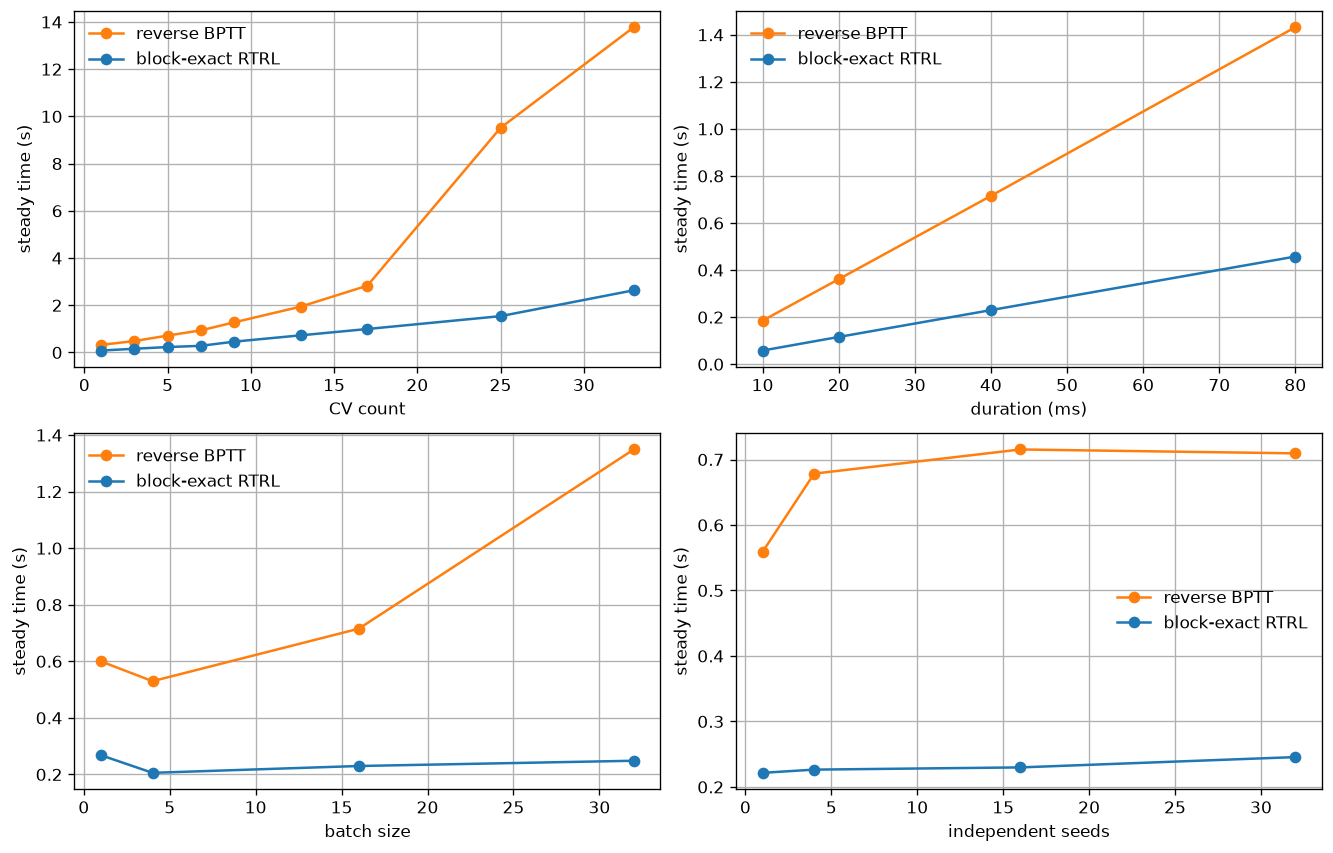

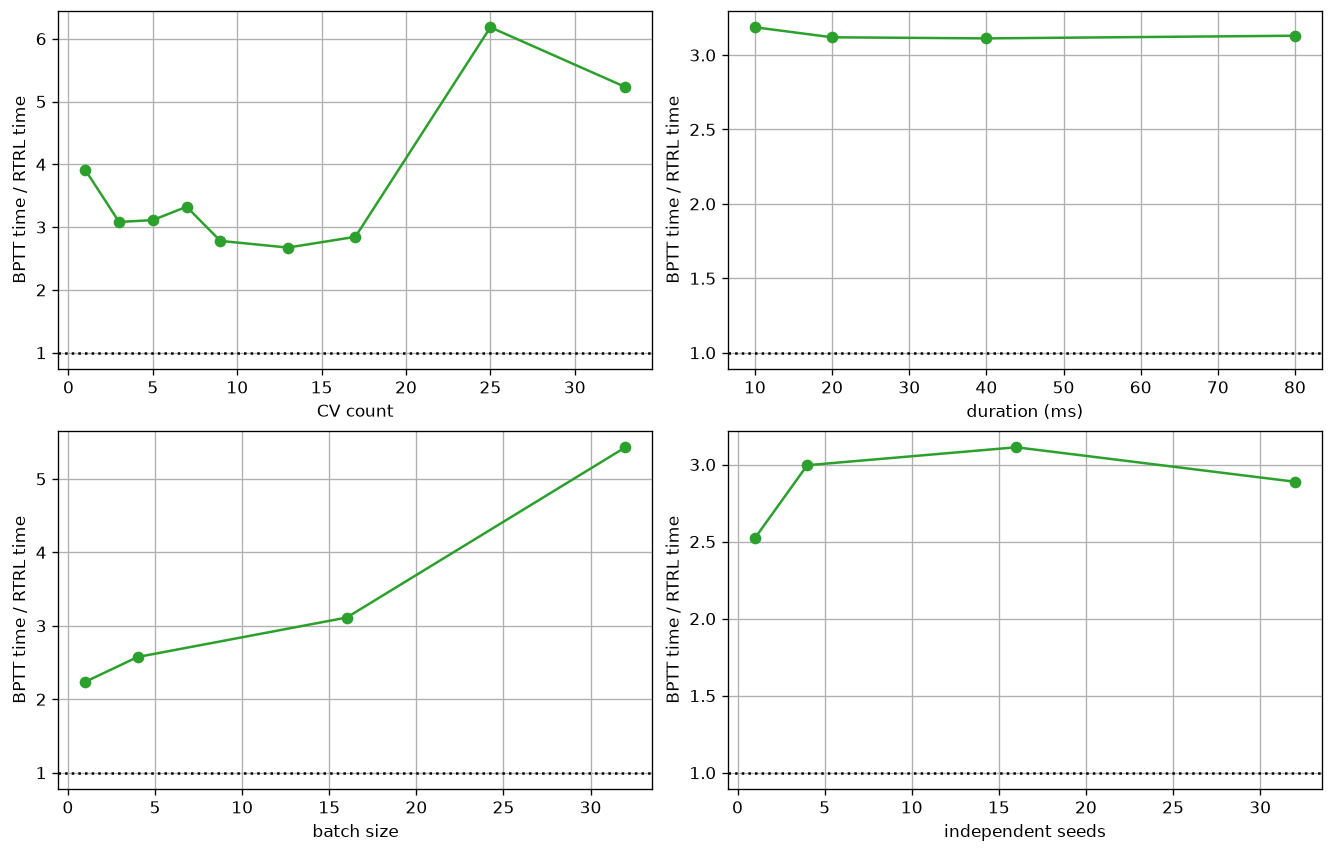

In [4]:
plot_metric("steady_median_seconds", "steady time (s)")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for panel, (axis, xlabel) in zip(axes.flat, AXES):
    rows = axis_slice(axis).drop_duplicates("config_id").sort_values(axis)
    panel.plot(rows[axis], rows.bptt_over_rtrl_time, marker="o", color="tab:green")
    panel.axhline(1.0, color="black", linestyle=":")
    panel.set(xlabel=xlabel, ylabel="BPTT time / RTRL time")
plt.show()

## XLA temporary、GPU allocation 与 RTRL carry

T 增长时 BPTT temporal tape 增长，而 RTRL eligibility carry 不随 T 变化。CV 增长同时增加 state 与每-seed参数方向，因此 RTRL carry 呈近似 `C^2`；batch 和 seed 对 block carry 近似线性。

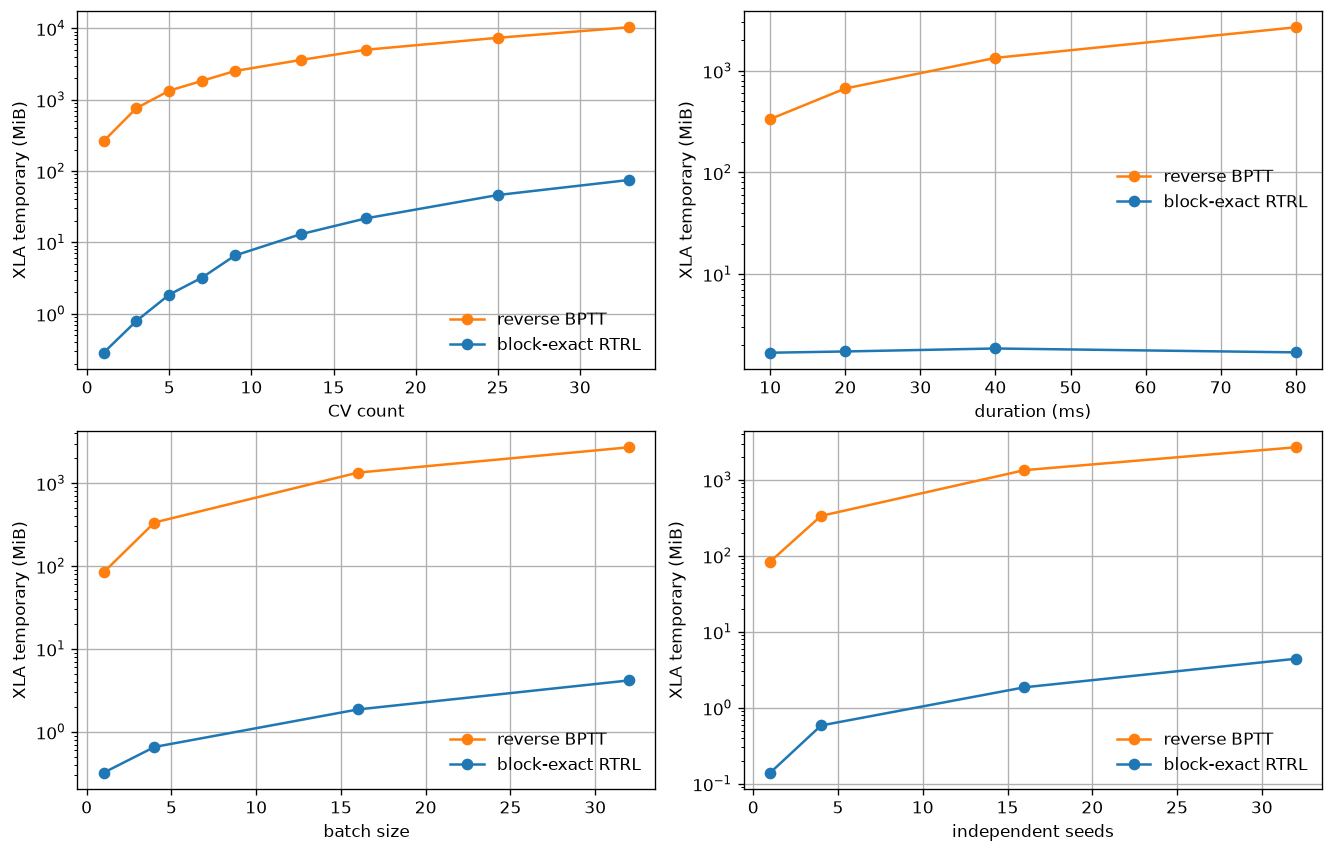

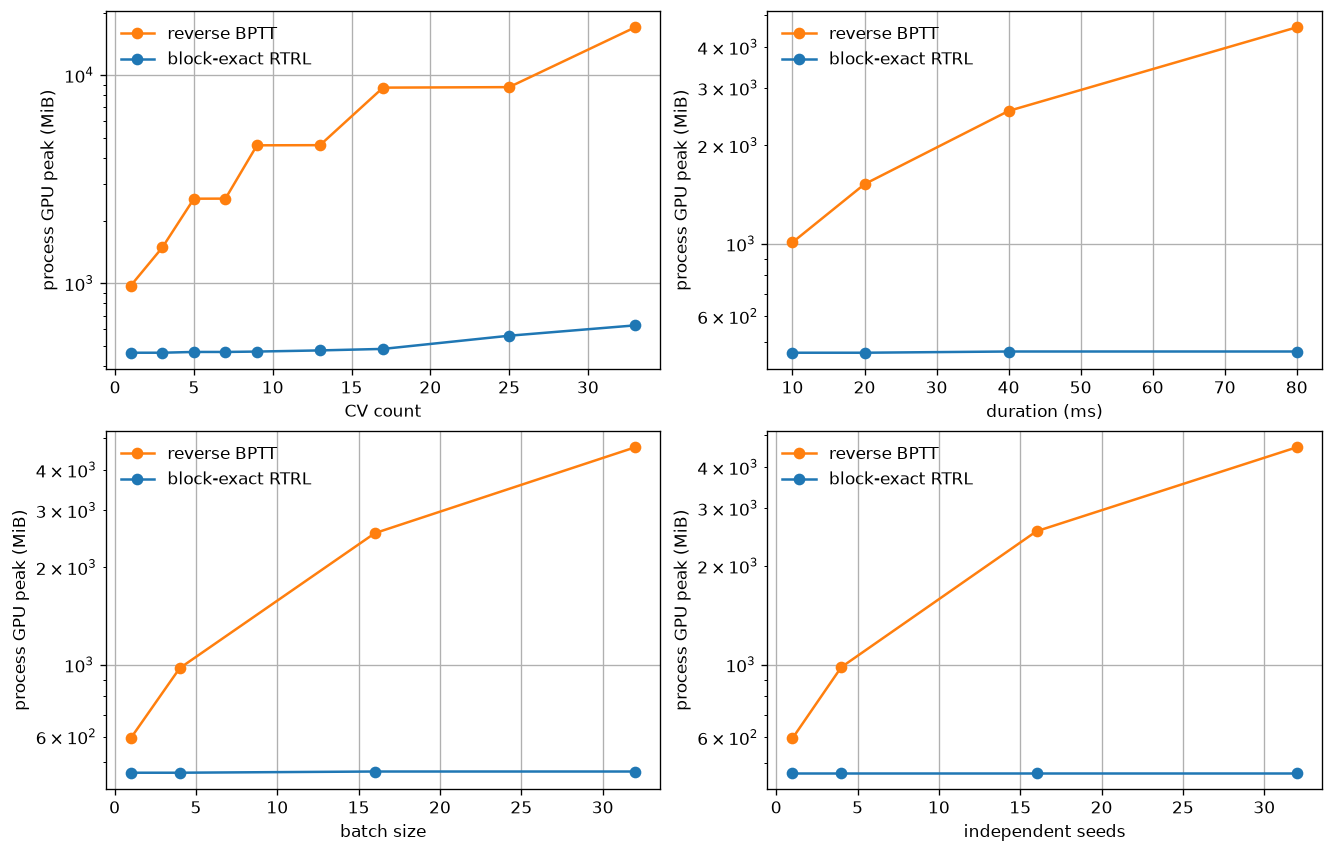

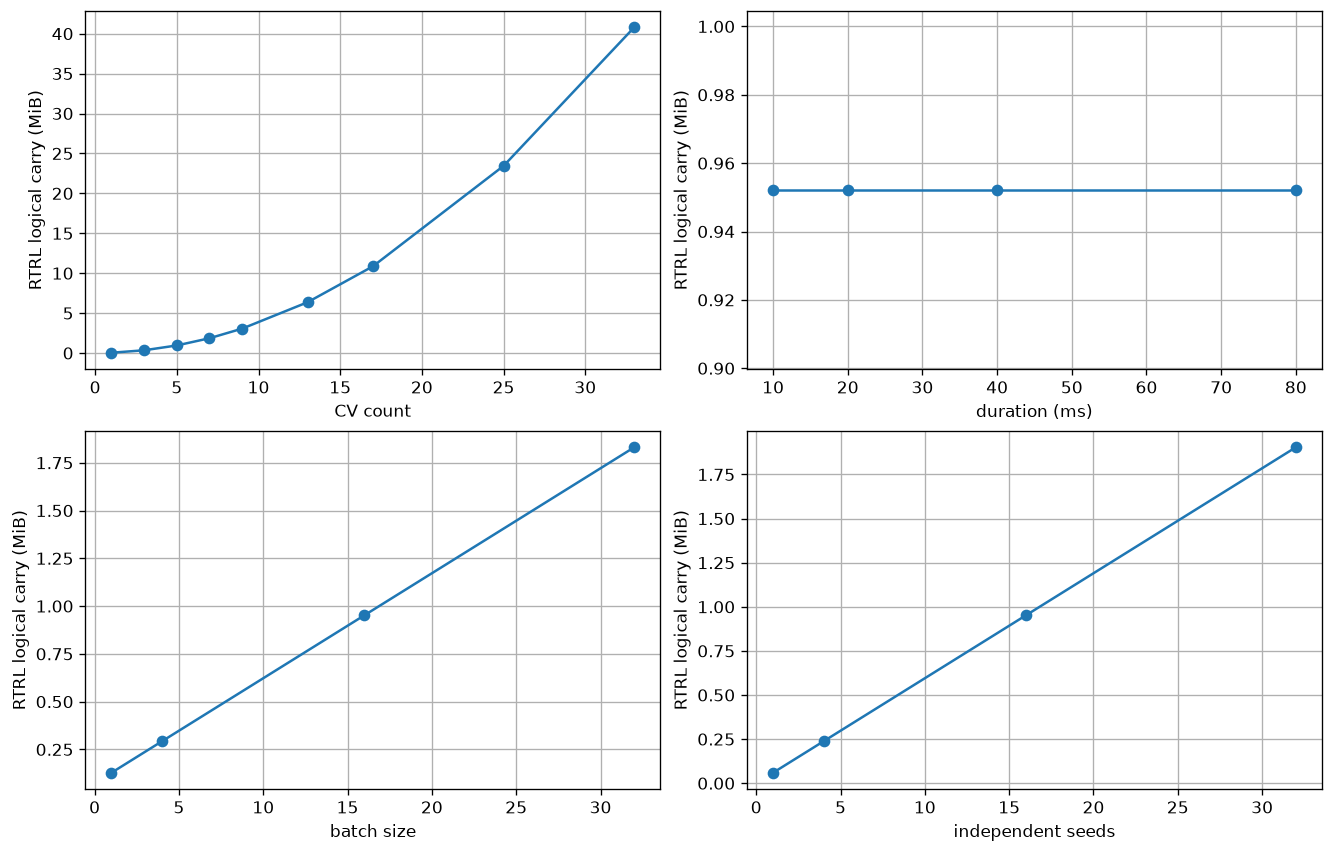

In [5]:
plot_metric("temporary_bytes", "XLA temporary (MiB)", scale=2**20, log_y=True)
plt.show()
plot_metric("gpu_peak_steady_bytes", "process GPU peak (MiB)", scale=2**20, log_y=True)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for panel, (axis, xlabel) in zip(axes.flat, AXES):
    rows = axis_slice(axis)
    rows = rows[rows.method == "rtrl"]
    panel.plot(rows[axis], rows.rtrl_carry_bytes / 2**20, marker="o", color=COLORS["rtrl"])
    panel.set(xlabel=xlabel, ylabel="RTRL logical carry (MiB)")
plt.show()

## Steady GPU utilization 与功耗

NVML utilization 表示采样窗口内设备是否繁忙，并不等价于达到峰值 FLOP/s。这里大多数 kernel 的 utilization 已接近100%，但功耗远低于A100上限；结合吞吐随seed/batch继续提高，可以判断 occupancy、指令混合和内存流量仍限制实际效率。

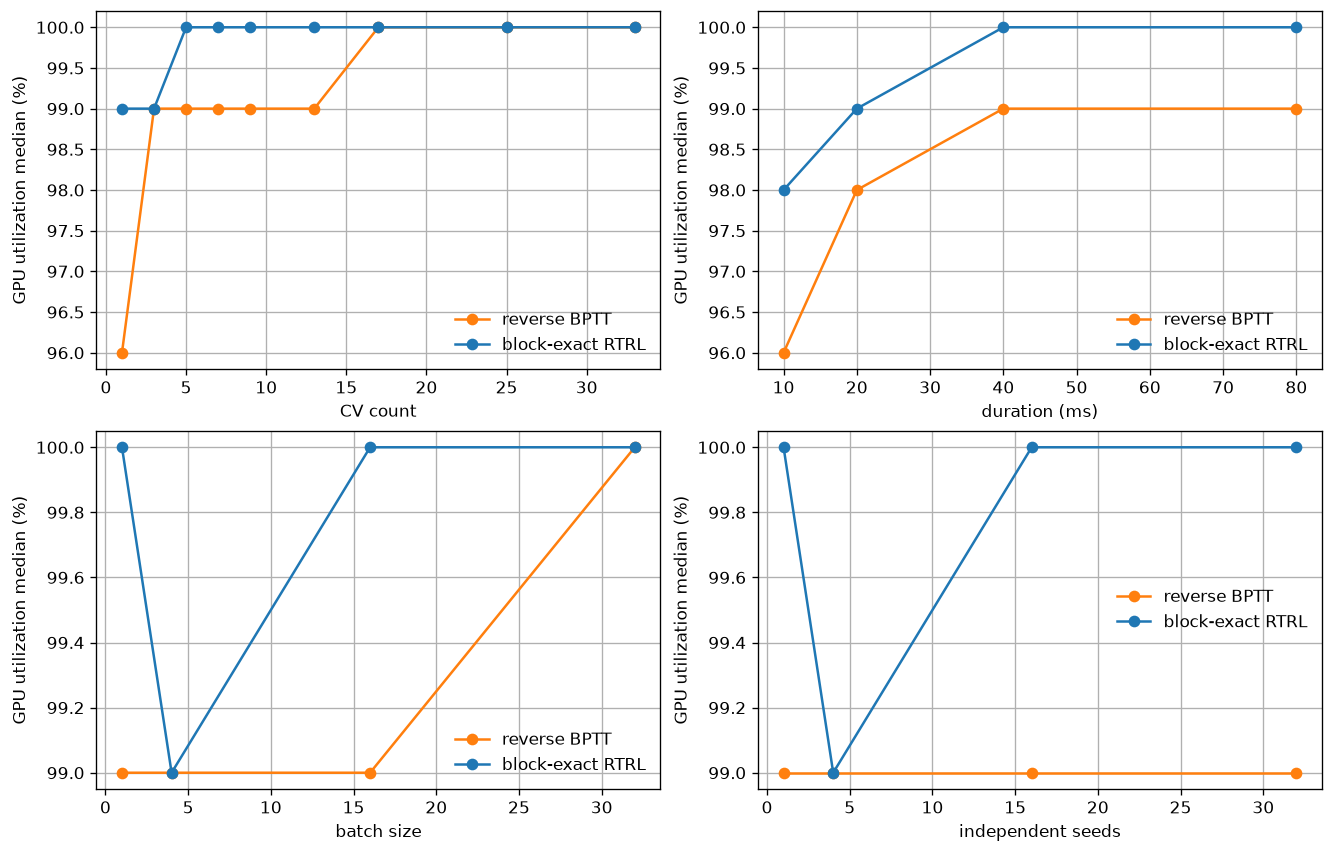

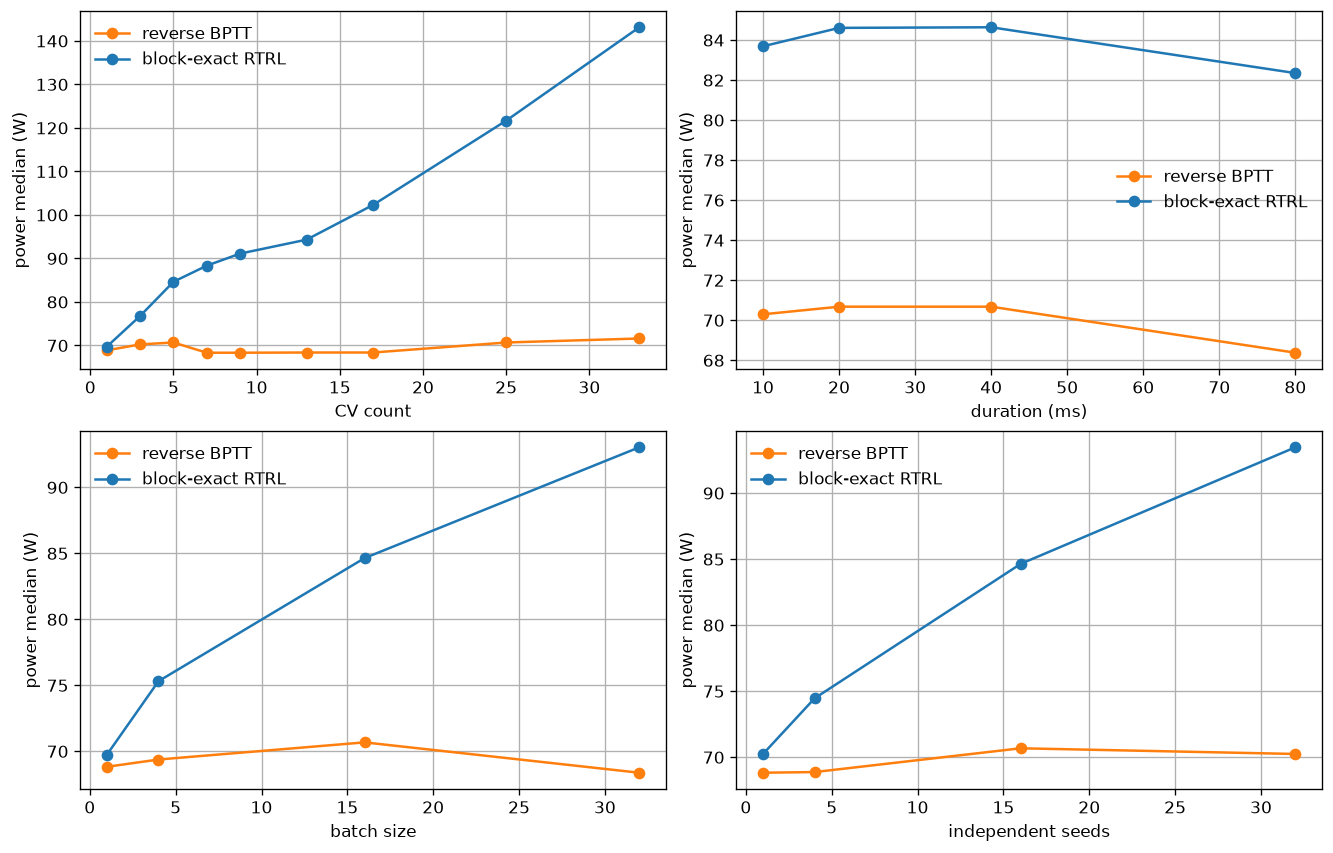

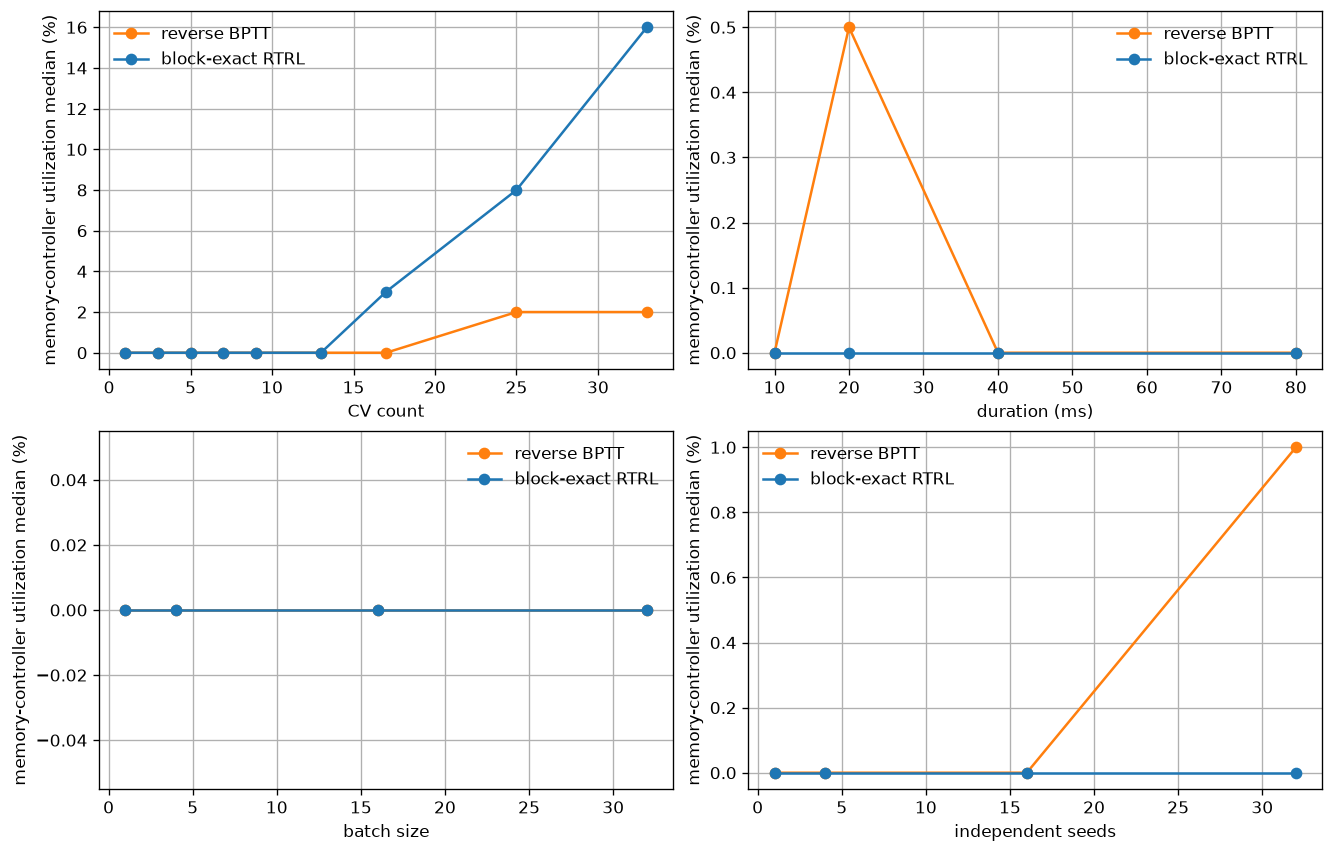

steady sample-count range: 5 to 1038


In [6]:
plot_metric("gpu_util_steady_median_percent", "GPU utilization median (%)")
plt.show()
plot_metric("gpu_power_steady_median_watts", "power median (W)")
plt.show()
plot_metric("gpu_memory_util_steady_median_percent", "memory-controller utilization median (%)")
plt.show()
print("steady sample-count range:", int(ok.gpu_samples_steady.min()), "to", int(ok.gpu_samples_steady.max()))

## 编译成本与吞吐

独立进程使 compile time 可比，也暴露了复杂 batch/CV shape 对编译器的真实成本。Throughput 使用 `seed × batch × time-step / second`，不等同于单细胞 latency。

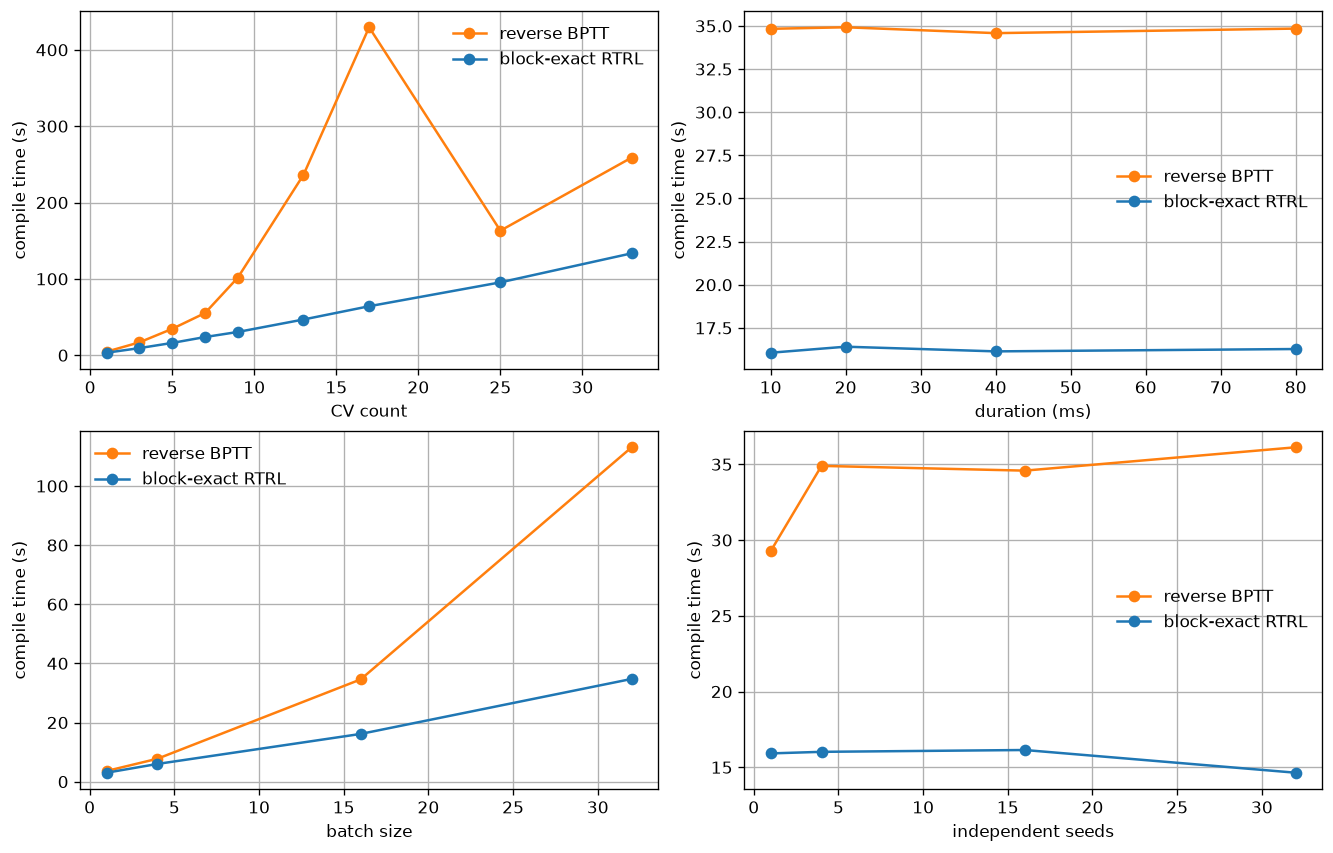

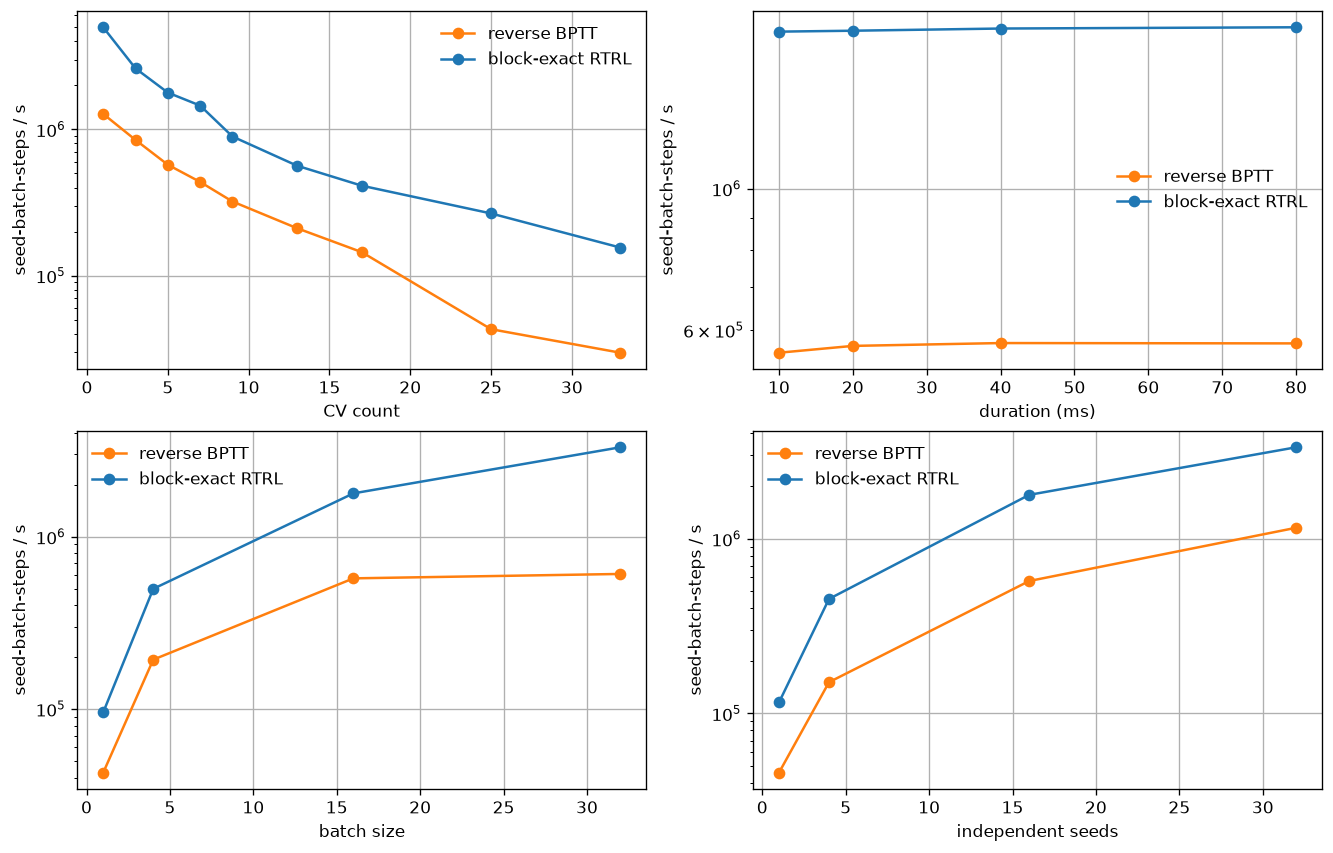

In [7]:
plot_metric("compile_seconds", "compile time (s)")
plt.show()
plot_metric("throughput_seed_batch_steps_per_second", "seed-batch-steps / s", log_y=True)
plt.show()

## 数值一致性

BPTT 与 RTRL 对同一个 fixed-parameter rollout 求导。绝对误差会随梯度量级和累加长度增长，因此同时报告相对误差。

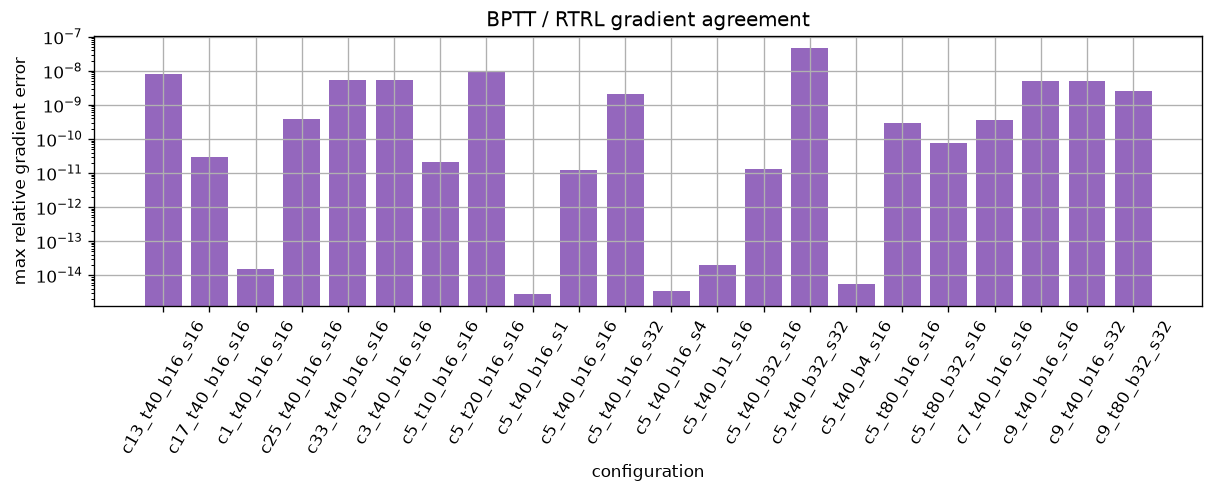

worst relative gradient error: 4.539645000624328e-08
worst loss absolute error: 6.775735528208314e-10


In [8]:
correctness = ok.drop_duplicates("config_id").sort_values("config_id")
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(correctness.config_id, correctness.gradient_max_rel_error, color="tab:purple")
ax.set_yscale("log")
ax.set(xlabel="configuration", ylabel="max relative gradient error", title="BPTT / RTRL gradient agreement")
ax.tick_params(axis="x", rotation=60)
plt.show()
print("worst relative gradient error:", correctness.gradient_max_rel_error.max())
print("worst loss absolute error:", correctness.loss_max_abs_error.max())

## 交互角点

单轴图固定其他三个维度。下面单独列出同时改变两个以上维度的角点，避免将其误作单轴趋势点。

In [9]:
dimension_columns = tuple(BASELINE)
different_axes = sum(ok[column] != value for column, value in BASELINE.items())
corners = ok[different_axes >= 2][
    [
        "config_id",
        "method",
        "steady_median_seconds",
        "compile_seconds",
        "temporary_bytes",
        "gpu_peak_steady_bytes",
        "rtrl_carry_bytes",
        "gpu_util_steady_median_percent",
        "gpu_power_steady_median_watts",
        "bptt_over_rtrl_time",
    ]
].sort_values(["config_id", "method"])
display(corners)

largest_id = "c9_t80_b32_s32"
largest = ok[ok.config_id == largest_id].set_index("method")
if len(largest) == 2:
    print("largest corner:", largest_id)
    print(
        f"  BPTT: {largest.loc['bptt', 'steady_median_seconds']:.3f}s, temp {largest.loc['bptt', 'temporary_bytes'] / 1e9:.2f} GB, peak {largest.loc['bptt', 'gpu_peak_steady_bytes'] / 1e9:.2f} GB"
    )
    print(
        f"  RTRL: {largest.loc['rtrl', 'steady_median_seconds']:.3f}s, temp {largest.loc['rtrl', 'temporary_bytes'] / 1e6:.2f} MB, carry {largest.loc['rtrl', 'rtrl_carry_bytes'] / 1e6:.2f} MB"
    )
    print(f"  time ratio: {largest.loc['bptt', 'bptt_over_rtrl_time']:.2f}x")

,config_id,method,steady_median_seconds,compile_seconds,temporary_bytes,gpu_peak_steady_bytes,rtrl_carry_bytes,gpu_util_steady_median_percent,gpu_power_steady_median_watts,bptt_over_rtrl_time
20,c5_t40_b32_s32,bptt,1.207326,115.825754,5675864056,9355395072,NaN,100.0,69.750,4.170986
21,c5_t40_b32_s32,rtrl,0.289458,30.983970,7280824,490733568,3840000.0,100.0,105.920,4.170986
26,c5_t80_b32_s16,bptt,2.692842,113.503960,5675532536,9357492224,NaN,100.0,68.585,5.401794
27,c5_t80_b32_s16,rtrl,0.498509,34.718443,4620216,494927872,1920000.0,100.0,93.470,5.401794
32,c9_t40_b16_s32,bptt,1.482164,165.352801,5298102768,9118416896,NaN,99.0,69.750,2.866522
33,c9_t40_b16_s32,rtrl,0.517060,32.147939,13749176,492830720,6414336.0,100.0,101.230,2.866522
34,c9_t80_b32_s32,bptt,4.892512,435.058262,21418056304,35949379584,NaN,100.0,70.160,3.522049
35,c9_t80_b32_s32,rtrl,1.389109,56.681954,27239864,505413632,12386304.0,100.0,123.860,3.522049


largest corner: c9_t80_b32_s32
  BPTT: 4.893s, temp 21.42 GB, peak 35.95 GB
  RTRL: 1.389s, temp 27.24 MB, carry 12.39 MB
  time ratio: 3.52x


## Large-CV 扩展

固定 `T40/B16/S16`，将CV轴扩展到13、17、25、33。RTRL carry理论上近似 `C^2`；实际墙钟还受GPU并行、kernel分解和编译策略影响。

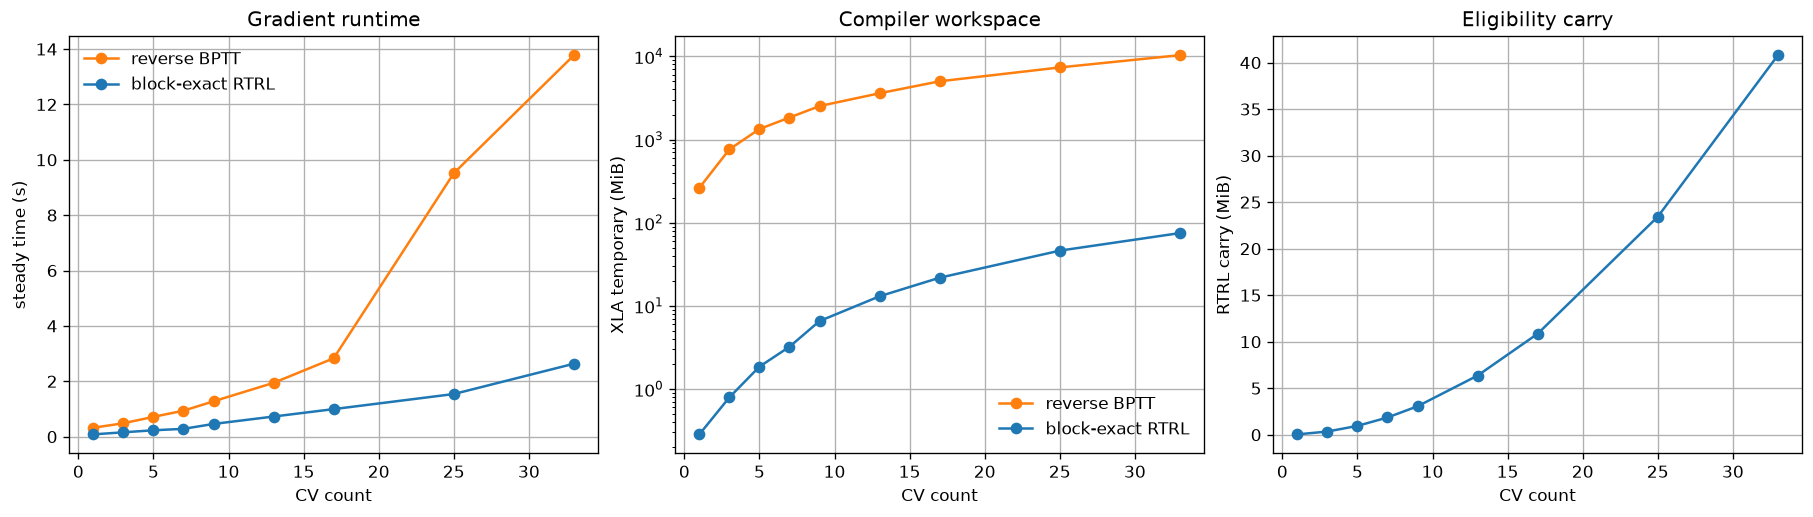

bptt large-CV runtime log-log exponent: 2.26
rtrl large-CV runtime log-log exponent: 1.35
RTRL carry log-log exponent across all CV points: 1.98


,n_cv,method,compile_seconds,steady_median_seconds,temporary_bytes,rtrl_carry_bytes,gpu_peak_steady_bytes,gpu_power_steady_median_watts,bptt_over_rtrl_time
36,13,bptt,236.262032,1.943324,3777343824,NaN,4833935360,68.380,2.674548
37,13,rtrl,46.799568,0.726599,13676728,6669312.0,499122176,94.320,2.674548
38,17,bptt,429.525872,2.830310,5259703752,NaN,9135194112,68.380,2.845733
39,17,rtrl,64.171393,0.994580,22855864,11384832.0,507510784,102.300,2.845733
40,25,bptt,163.136557,9.516540,7720923016,NaN,9185525760,70.680,6.182366
41,25,rtrl,95.443895,1.539304,48384184,24576000.0,587202560,121.680,6.182366
42,33,bptt,258.859082,13.779898,10847259232,NaN,17811111936,71.600,5.230855
43,33,rtrl,133.466470,2.634349,78672824,42780672.0,658505728,143.135,5.230855


In [10]:
cv_rows = axis_slice("n_cv")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for method in ("bptt", "rtrl"):
    rows = cv_rows[cv_rows.method == method]
    axes[0].plot(rows.n_cv, rows.steady_median_seconds, marker="o", color=COLORS[method], label=LABELS[method])
    axes[1].plot(rows.n_cv, rows.temporary_bytes / 2**20, marker="o", color=COLORS[method], label=LABELS[method])
rtrl_cv = cv_rows[cv_rows.method == "rtrl"]
axes[2].plot(rtrl_cv.n_cv, rtrl_cv.rtrl_carry_bytes / 2**20, marker="o", color=COLORS["rtrl"])
axes[0].set(xlabel="CV count", ylabel="steady time (s)", title="Gradient runtime")
axes[1].set(xlabel="CV count", ylabel="XLA temporary (MiB)", title="Compiler workspace")
axes[1].set_yscale("log")
axes[2].set(xlabel="CV count", ylabel="RTRL carry (MiB)", title="Eligibility carry")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
plt.show()

large = cv_rows[cv_rows.n_cv >= 13]
for method in ("bptt", "rtrl"):
    rows = large[large.method == method]
    exponent = np.polyfit(np.log(rows.n_cv), np.log(rows.steady_median_seconds), 1)[0]
    print(f"{method} large-CV runtime log-log exponent: {exponent:.2f}")
carry_exponent = np.polyfit(np.log(rtrl_cv.n_cv), np.log(rtrl_cv.rtrl_carry_bytes), 1)[0]
print(f"RTRL carry log-log exponent across all CV points: {carry_exponent:.2f}")
display(
    large[
        [
            "n_cv",
            "method",
            "compile_seconds",
            "steady_median_seconds",
            "temporary_bytes",
            "rtrl_carry_bytes",
            "gpu_peak_steady_bytes",
            "gpu_power_steady_median_watts",
            "bptt_over_rtrl_time",
        ]
    ]
)

## Ordinary Hines vs recursive-doubling backsub

固定 `T40/B16/S16`，比较C9/17/25/33。Ordinary按root→leaf level执行，总work线性但依赖深度为tree depth；recursive doubling使用更多work换取对数backsub span。默认主曲线仍使用recursive。

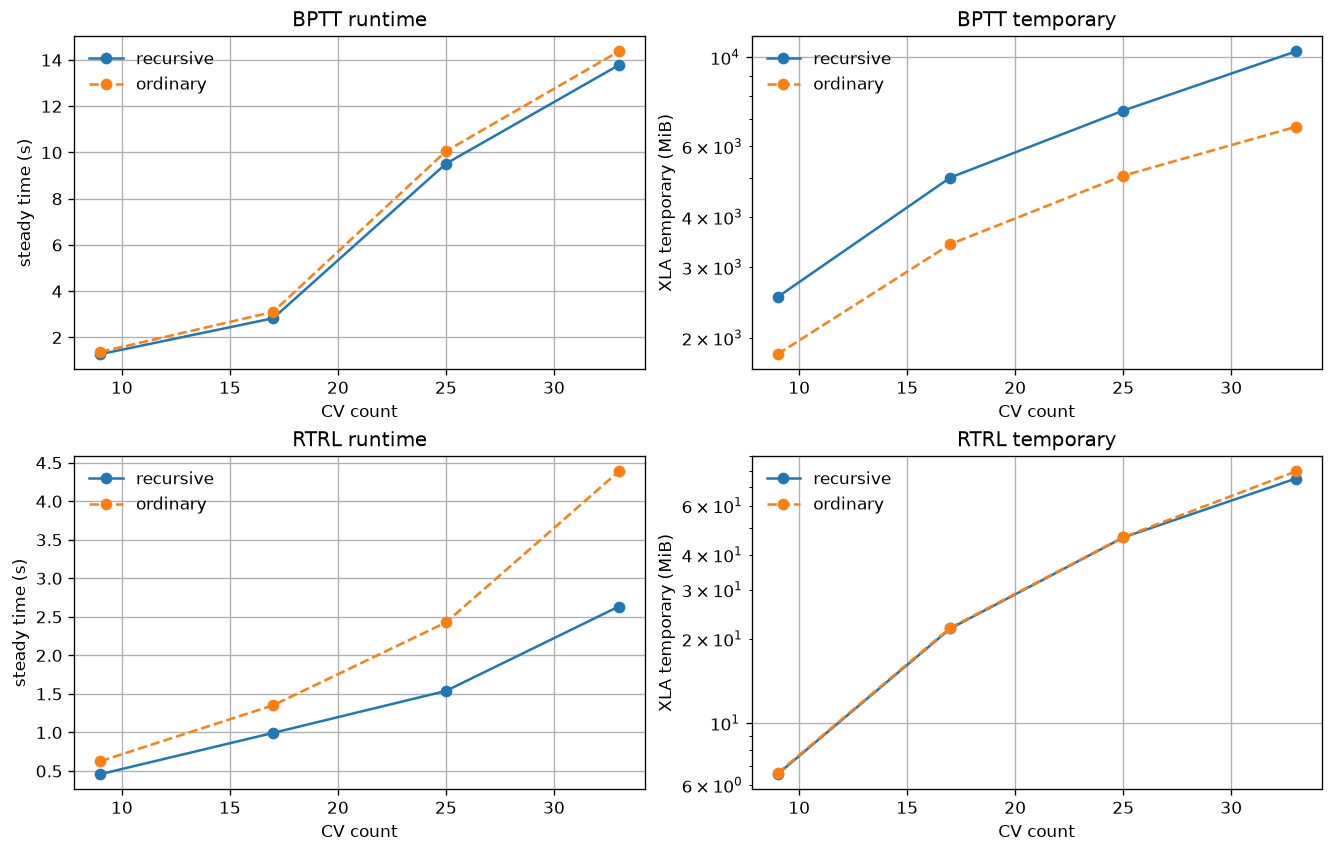

steady_median_seconds            temporary_bytes  \
backsub                                  ordinary  recursive        ordinary   
config_id       n_cv method                                                    
c17_t40_b16_s16 17   bptt                3.105854   2.830310    3.589519e+09   
                     rtrl                1.353377   0.994580    2.300742e+07   
c25_t40_b16_s16 25   bptt               10.057664   9.516540    5.315789e+09   
                     rtrl                2.428033   1.539304    4.850502e+07   
c33_t40_b16_s16 33   bptt               14.375604  13.779898    7.039670e+09   
                     rtrl                4.387939   2.634349    8.346335e+07   
c9_t40_b16_s16  9    bptt                1.374668   1.276080    1.908792e+09   
                     rtrl                0.626760   0.458880    6.927288e+06   

                                                          derived  \
backsub                         recursive ordinary/recursive time   
config_id       n_cv method                                         
c17_t40_b16_s16 17   bptt    5.259704e+09                1.097355   
                     rtrl    2.285586e+07                1.360752   
c25_t40_b16_s16 25   bptt    7.720923e+09                1.056861   
                     rtrl    4.838418e+07                1.577358   
c33_t40_b16_s16 33   bptt    1.084726e+10                1.043230   
                     rtrl    7.867282e+07                1.665664   
c9_t40_b16_s16  9    bptt    2.649135e+09                1.077258   
                     rtrl    6.878904e+06                1.365845   

                                                     
backsub                     ordinary/recursive temp  
config_id       n_cv method                          
c17_t40_b16_s16 17   bptt                  0.682456  
                     rtrl                  1.006631  
c25_t40_b16_s16 25   bptt                  0.688491  
                     rtrl                  1.002497  
c33_t40_b16_s16 33   bptt                  0.648981  
                     rtrl                  1.060892  
c9_t40_b16_s16  9    bptt                  0.720534  
                     rtrl                  1.007034

In [11]:
ab = all_ok[
    all_ok.n_cv.isin([9, 17, 25, 33]) & (all_ok.duration_ms == 40) & (all_ok.batch_size == 16) & (all_ok.n_seed == 16)
].copy()
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for row, method in enumerate(("bptt", "rtrl")):
    subset = ab[ab.method == method]
    for backsub, style in (("recursive", "-"), ("ordinary", "--")):
        values = subset[subset.backsub == backsub].sort_values("n_cv")
        axes[row, 0].plot(values.n_cv, values.steady_median_seconds, marker="o", linestyle=style, label=backsub)
        axes[row, 1].plot(values.n_cv, values.temporary_bytes / 2**20, marker="o", linestyle=style, label=backsub)
    axes[row, 0].set(xlabel="CV count", ylabel="steady time (s)", title=f"{method.upper()} runtime")
    axes[row, 1].set(xlabel="CV count", ylabel="XLA temporary (MiB)", title=f"{method.upper()} temporary")
    axes[row, 1].set_yscale("log")
    axes[row, 0].legend(frameon=False)
    axes[row, 1].legend(frameon=False)
plt.show()

ab_pivot = ab.pivot(
    index=["config_id", "n_cv", "method"], columns="backsub", values=["steady_median_seconds", "temporary_bytes"]
)
ab_pivot[("derived", "ordinary/recursive time")] = (
    ab_pivot[("steady_median_seconds", "ordinary")] / ab_pivot[("steady_median_seconds", "recursive")]
)
ab_pivot[("derived", "ordinary/recursive temp")] = (
    ab_pivot[("temporary_bytes", "ordinary")] / ab_pivot[("temporary_bytes", "recursive")]
)
display(ab_pivot)

In [12]:
def load_trial_arrays(row):
    return np.load(Path(row.result_directory) / "trials" / row.gradient_file)


backsub_errors = []
for (config_id, method), group in ab.groupby(["config_id", "method"]):
    modes = {row.backsub: row for row in group.itertuples()}
    if set(modes) != {"recursive", "ordinary"}:
        continue
    recursive = load_trial_arrays(modes["recursive"])
    ordinary = load_trial_arrays(modes["ordinary"])
    difference = np.abs(recursive["gradient"] - ordinary["gradient"])
    scale = np.maximum(np.abs(recursive["gradient"]), 1e-30)
    backsub_errors.append(
        {
            "config_id": config_id,
            "method": method,
            "gradient_max_abs_error": difference.max(),
            "gradient_max_rel_error": (difference / scale).max(),
            "loss_max_abs_error": np.max(np.abs(recursive["loss"] - ordinary["loss"])),
        }
    )
backsub_errors = pd.DataFrame(backsub_errors)
display(backsub_errors)
print("worst ordinary/recursive relative gradient error:", backsub_errors.gradient_max_rel_error.max())

,config_id,method,gradient_max_abs_error,gradient_max_rel_error,loss_max_abs_error
0,c17_t40_b16_s16,bptt,1.075089e-06,5.768022e-10,1.599005e-10
1,c17_t40_b16_s16,rtrl,5.647976e-07,3.036128e-10,4.168328e-10
2,c25_t40_b16_s16,bptt,2.527564e-05,1.270895e-08,3.515197e-10
3,c25_t40_b16_s16,rtrl,2.526458e-05,1.270339e-08,5.587708e-10
4,c33_t40_b16_s16,bptt,4.925980e-06,5.421827e-09,5.083649e-10
5,c33_t40_b16_s16,rtrl,9.546122e-06,5.413093e-09,3.337775e-10
6,c9_t40_b16_s16,bptt,1.405316e-05,4.931805e-09,2.874572e-10
7,c9_t40_b16_s16,rtrl,1.410732e-05,4.950816e-09,1.257376e-10


worst ordinary/recursive relative gradient error: 1.270894727246979e-08


## 结论边界

- Full suite 使用完整单轴点和四个交互角点；large-CV结果继续扩展同一CV单轴。
- seed block `vmap` 让 S 轴表示真正独立的 multistart throughput，而不是跨 seed 零块。
- 正常 gradient kernel 不含 diagnostics 或 Adam；两种方法都返回相同的逐步 losses 和命名总梯度。
- Large-CV测试到C33仍未耗尽80GB显存，但BPTT从C25开始出现明显运行时间拐点。
- Ordinary backsub降低BPTT temporary但在当前并行轴下更慢；RTRL几乎没有temporary收益且明显更慢。C17→C25拐点在ordinary模式仍存在。